# Machine Learning for Multibody System Dynamics

## **Session 2-4:** Joint Clearance & Predictive Maintenance

Grzegorz Orzechowski & Peter Manzl

> RNN trained on sensors for the mechanism with clearance.

## Delivery Note
- This notebook shifts the session from regression to classification and maintenance.
- Keep the focus on engineering interpretation, not only on model training.

## Session 2 So Far → What's New

| Session | Task | Output type | Loss | Model |
|---------|------|------------|------|-------|
| 2-1 | Learn ODE derivatives | continuous | MSE | MLP |
| 2-2 | Predict full trajectory | continuous | MSE | MLP |
| 2-3 | Find best hyperparameters | — | — | grid search |
| **2-4** | **Detect joint clearance** | **class label** | **cross-entropy** | **GRU** |

Two things change at once:
1. **Regression → Classification** — the answer is a category, not a number.
2. **MLP → GRU** — the input is a time series; order matters. A **GRU** (*Gated Recurrent Unit*) is a small recurrent network that reads the sequence step-by-step and carries a hidden state from one step to the next; the full architecture and why it suits this task are unpacked later in the notebook.

## The Engineering Problem: Joint Clearance

**Clearance** (backlash) is a radial gap between mating parts — pin in bearing, journal in sleeve.

![Bearing clearance](../figures/clearance-example.png)

**Why it matters:**
- **Impact loads** — intermittent contact creates shock pulses at each engagement
- **Wear acceleration** — repeated impacts cause surface pitting and fatigue
- **NVH** — rattle and noise degrade machine quality and operator comfort
- **Precision loss** — backlash reduces positioning accuracy in robots and CNC machines

**Predictive maintenance goal:**  
Detect abnormal clearance growth *before* catastrophic failure — using sensors already on the machine.

## Slider-Crank with Joint Clearance

![Slider-crank with clearance](../figures/slider-crank-clearance.png)

**Mechanism:** crank AB → coupler BC → slider C  
**Clearance location:** radial gap Δ at pin joint A

**Simulation approach:**
- Lagrange equations of motion for the three-link assembly
- Clearance modelled as **penalty contact**: $F_n = k \cdot \text{gap}$ when gap ≤ 0
- Viscous damping $F_d = c \cdot \dot{x}$ in the contact direction
- Two accelerometers record signals during operation

## What Clearance Does to Accelerometer Signals

| Feature | No clearance | With clearance |
|---------|-------------|---------------|
| Time domain | smooth, periodic | sharp impact **spikes** |
| Frequency content | fundamental + low harmonics | broadband energy, high-frequency content |
| RMS | low | higher |
| Kurtosis | ~3 (Gaussian) | **>3** — signal "peakiness" |

Impact spikes: each lift-off and re-engagement at the pin produces a short, high-amplitude pulse.  
These are visible in the **time domain** and show up as elevated broadband energy in the **power spectral density (PSD)**.

In [1]:
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from scipy.signal import welch

## Preprocessing: Clearance Analysis & Its Impact on Acceleration Signals

- **Typical Clearance Analysis**  
  - **Geometric Inspection**: Measure gap Δ by coordinate‐measuring or optical methods.  
  - **Static Load Tests**: Apply preload to see “take-up” angle or displacement before contact.  
  - **Dynamic Characterization**:  
    - Sweep excitation (sinusoidal or random) to identify contact “stiffness” and damping.  
    - Use modal testing to see how the gap alters natural frequencies.

- **Effects on Acceleration Signals**  
  - **Impact Spikes**: Each “lift-off” and re-engagement at clearance produces short, high‐amplitude pulses.  
  - **High-Frequency Content**: Sharp impacts inject broadband noise and excite higher modes.  
  - **Harmonic & Sideband Generation**: Periodic impacts at crank frequency ω (and its multiples) show up as sidebands around ω in the spectrum.  
  - **RMS & Kurtosis Increase**: Overall vibration energy and signal “peakedness” rise as clearance grows—key features for anomaly detection.  

### Data loading from .npz files

The following data are stored for each 1s sequence:
- `pos`: Generalized positions,
- `vel`: Generalized velocities,
- `acc`: Generalized accelerations,
- `acc1`: Accelerometer values x,
- `acc2`: Accelerometer values y,
- `t`: Time vector,
- `label`: Label indicating if the model contains clearance or not. 

In [2]:
# Example: use only 'vel' and 'acc' with sequence length 100 and stride 50
seq_length = 100
stride = 50

# used_vars = ['vel', 'acc'] # works well on this
used_vars = ['acc1', 'acc2']

sequences = []
labels = []

for path in glob.glob("../data/*.npz"):
    data = np.load(path)
    arrays = [data[var] for var in used_vars]
    combined = np.column_stack(arrays)
    label = int(data['label'])

    T = combined.shape[0]
    for start in range(0, T - seq_length + 1, stride):
        segment = combined[start:start + seq_length].T  # [features, seq_len]
        sequences.append(segment)
        labels.append(label)

X = np.array(sequences)
y = np.array(labels)

## Signal Comparison: No Clearance

Time-domain signal and Power Spectral Density for the **healthy** mechanism ($\Delta = 0$).

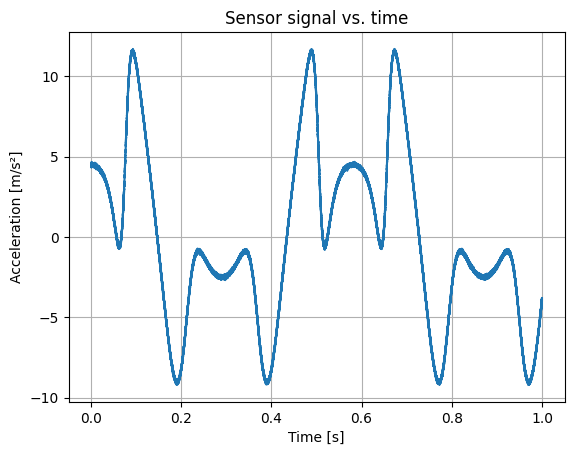

In [3]:
data = np.load("../data/data_clear_0_inivel_0.npz")
plt.plot(data['t'], data['acc1'])  # Plot first accelerometer channel over time
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [m/s²]")
plt.title("Sensor signal vs. time")
plt.grid(True)
plt.show()

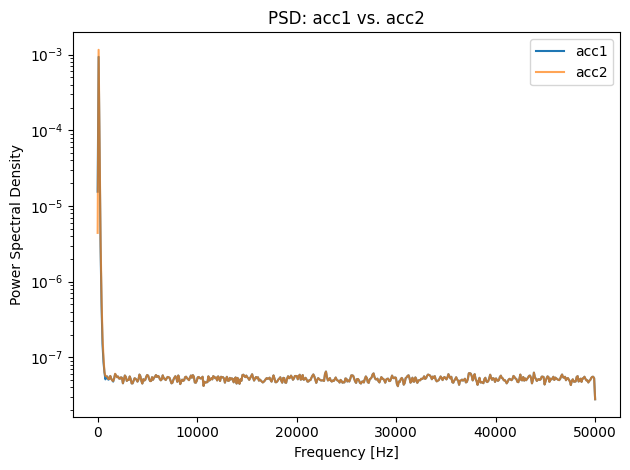

In [4]:
# 2. Extract arrays
t    = data['t']
acc1 = data['acc1']
acc2 = data['acc2']

# 3. Sampling frequency
fs = 1.0 / np.mean(np.diff(t))

# 4. Compute PSDs
f, Pxx1 = welch(acc1, fs=fs, nperseg=1024)
_, Pxx2 = welch(acc2, fs=fs, nperseg=1024)

# 5. Plot PSDs
plt.figure()
plt.semilogy(f, Pxx1, label='acc1')
plt.semilogy(f, Pxx2, label='acc2', alpha=0.7)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power Spectral Density')
plt.title('PSD: acc1 vs. acc2')
plt.legend()
plt.tight_layout()
plt.show()

## Signal Comparison: With Clearance ($\Delta = 200\,\mu$ m)

Same mechanism — same operating conditions — different joint gap.

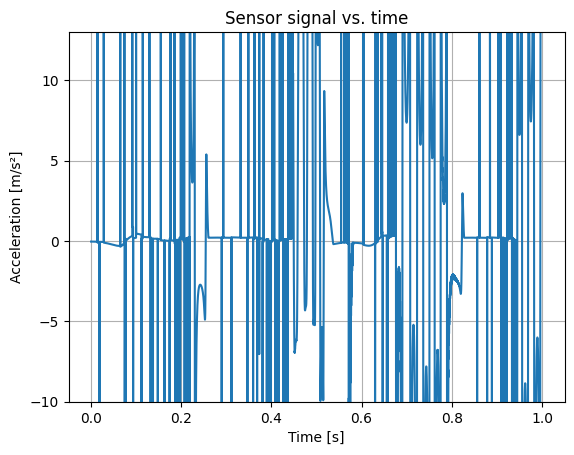

In [5]:
data = np.load("../data/data_clear_200_inivel_0.npz")
plt.plot(data['t'], data['acc1'])  # Plot first accelerometer channel over time
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [m/s²]")
plt.title("Sensor signal vs. time")
plt.ylim([-10, 13])
plt.grid(True)
plt.show()

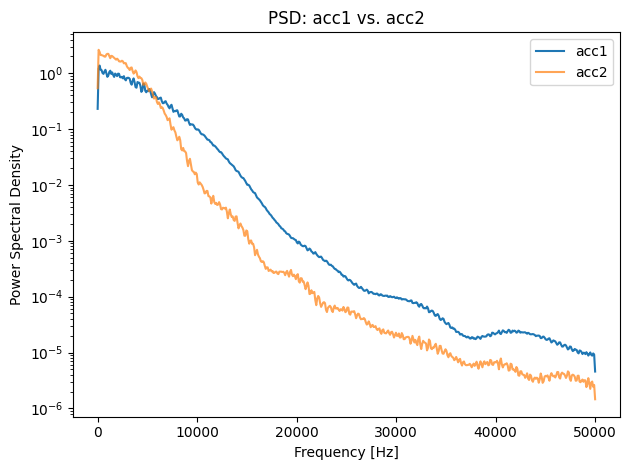

In [6]:
# 2. Extract arrays
t    = data['t']
acc1 = data['acc1']
acc2 = data['acc2']

# 3. Sampling frequency
fs = 1.0 / np.mean(np.diff(t))

# 4. Compute PSDs
f, Pxx1 = welch(acc1, fs=fs, nperseg=1024)
_, Pxx2 = welch(acc2, fs=fs, nperseg=1024)

# 5. Plot PSDs
plt.figure()
plt.semilogy(f, Pxx1, label='acc1')
plt.semilogy(f, Pxx2, label='acc2', alpha=0.7)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power Spectral Density')
plt.title('PSD: acc1 vs. acc2')
plt.legend()
plt.tight_layout()
plt.show()

## Interactive Burst

You can see the difference visually.  
If you had to build an automated classifier, would you use:

- The **raw time-domain signal** — captures spike shape and amplitude
- The **frequency content (PSD)** — captures spectral energy distribution
- **Both** — let the model decide what's relevant

Which choice fits best with a neural network approach?

## From Raw Signal to Model Input

We don't feed the entire 1 s recording at once. Instead, we use a **sliding window**:

```
seq_length = 100  samples
stride     = 50   samples  (50% overlap)
```

Each window becomes one training sample:
- Shape per sample: `[features=2, seq_len=100]`
- Features: `acc1` (x-direction) and `acc2` (y-direction)
- Label: `0` = no clearance, `1` = has clearance

With overlap, one recording produces many samples → more data, better generalization.

> **Why 100 samples?** Long enough to capture several impact cycles; short enough to be computationally cheap.

## Train / Validation / Test Split

We use a **three-way stratified split** — 70 / 15 / 15.

`stratify=y` ensures both classes appear in roughly the same proportion in all three sets.  
Without stratification, a random split could put most "faulty" samples in the test set.

| Set | Purpose | Size |
|-----|---------|------|
| **Train** | update weights | 70% |
| **Val** | monitor overfitting, early stopping | 15% |
| **Test** | final unbiased evaluation | 15% |

Note the difference from 2-2: here we explicitly separate validation and test sets — the test set is *never* seen during training.

In [7]:
# Shuffle and split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)
# 0.1765 ≈ 15% / 85% to keep the right ratio

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 2798, Val: 600, Test: 600


## Define PyTorch Dataset and DataLoaders

This custom dataset wraps your sequence data and labels so you can use it with PyTorch’s DataLoader.

In [8]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # [N, features, seq_len]
        self.y = torch.tensor(y, dtype=torch.long)     # [N]
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = SequenceDataset(X_train, y_train)
val_dataset = SequenceDataset(X_val, y_val)
test_dataset = SequenceDataset(X_test, y_test)

# Create data loaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

## Why GRU? Sequence Models for Time Series

An MLP treats all inputs as **independent features** — it has no notion of "this came before that."  
Accelerometer data is a **time series**: the order of samples carries information about the impact dynamics.

**Recurrent networks** process sequences step-by-step, maintaining a hidden state:

$$h_t = \text{GRU}(x_t,\, h_{t-1})$$

| Model | Handles sequences | Parameters | Notes |
|-------|:-----------------:|-----------|-------|
| MLP | ✗ | fewest | order-blind |
| LSTM | ✓ | most | cell + hidden state |
| **GRU** | **✓** | **fewer than LSTM** | **simpler, comparable accuracy** |

GRU = Gated Recurrent Unit — uses reset and update gates to control memory flow.  
Simpler than LSTM with often similar performance on short sequences.

## GRU Classifier Architecture

```
Input:  [batch, seq_len=100, features=2]   (after transpose)
         ↓
GRU:    hidden_size = 32
         ↓  (take final hidden state h_n)
FC:     32 → 2   (one logit per class)
         ↓
CrossEntropyLoss applies softmax internally
```

The final hidden state $h_n$ summarizes the entire sequence — it's the GRU's "verdict" after reading all 100 time steps.  
The fully connected layer then maps it to two class scores.

In [9]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size=47, hidden_size=32, num_classes=2):
        super(GRUClassifier, self).__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # x shape: [batch_size, features, seq_len] ➜ transpose to [batch_size, seq_len, features]
        x = x.permute(0, 2, 1)
        _, h_n = self.gru(x)  # h_n: [1, batch_size, hidden_size]
        out = self.fc(h_n.squeeze(0))  # [batch_size, num_classes]
        return out

## From Regression to Classification

In 2-1/2-2 we minimized **MSE** on a continuous output.  
Here the output is a **class probability** — we use **cross-entropy loss**:

$$\mathcal{L} = -\sum_c y_c \log \hat{p}_c$$

where $y_c = 1$ for the true class and $\hat{p}_c$ is the predicted probability.

PyTorch's `CrossEntropyLoss` combines `softmax` + `log` + `NLLLoss` in one step — do **not** apply softmax manually before passing to the loss.

| | Regression | Classification |
|-|-----------|---------------|
| Output | continuous value | class probabilities |
| Loss | MSE | cross-entropy |
| Metric | RMSE, R² | accuracy, F1, confusion matrix |

## Setup training utilities

This defines the model, loss function, optimizer, and device.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = GRUClassifier(input_size=X_train.shape[1]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using device: cpu


## Training

| Parameter | Value |
|-----------|-------|
| Optimizer | Adam |
| Learning rate | $10^{-3}$ |
| Loss | CrossEntropyLoss |
| Epochs | up to 20 |
| Early stopping patience | 7 |
| Batch size | 32 |

Only 20 epochs — the GRU converges quickly on this task because the signal difference between classes is large.

## Model Training: the GRU with validation

We’ll track training and validation loss, and optionally stop early if validation doesn’t improve for several epochs.

In [11]:
num_epochs = 20
best_val_loss = float('inf')
patience = 7
wait = 0

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    # Early stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        wait = 0
        torch.save(model.state_dict(), "best_model.pt")  # save best model
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.")
            break

Epoch 1/20 | Train Loss: 0.5954 | Val Loss: 0.5102
Epoch 2/20 | Train Loss: 0.3653 | Val Loss: 0.2420
Epoch 3/20 | Train Loss: 0.2116 | Val Loss: 0.1481
Epoch 4/20 | Train Loss: 0.1190 | Val Loss: 0.0944
Epoch 5/20 | Train Loss: 0.0947 | Val Loss: 0.0814
Epoch 6/20 | Train Loss: 0.0901 | Val Loss: 0.0618
Epoch 7/20 | Train Loss: 0.0776 | Val Loss: 0.1747
Epoch 8/20 | Train Loss: 0.1749 | Val Loss: 0.1581
Epoch 9/20 | Train Loss: 0.1343 | Val Loss: 0.1231
Epoch 10/20 | Train Loss: 0.1149 | Val Loss: 0.1061
Epoch 11/20 | Train Loss: 0.1015 | Val Loss: 0.0905
Epoch 12/20 | Train Loss: 0.0907 | Val Loss: 0.0813
Epoch 13/20 | Train Loss: 0.0835 | Val Loss: 0.0716
Early stopping triggered.


## Evaluation and testing: Plot training history

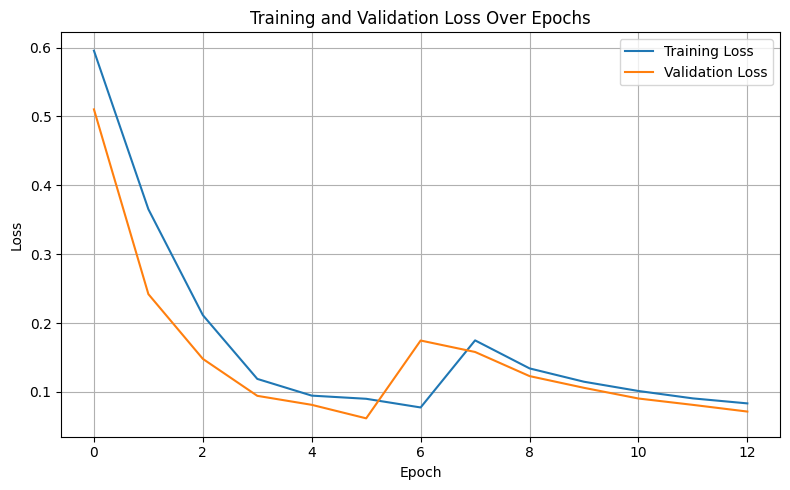

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Evaluation: Confusion Matrix

Accuracy alone can be misleading — especially for imbalanced classes.  
The confusion matrix shows **what kind of mistakes** the model makes.

|  | Predicted: No clearance | Predicted: Has clearance |
|--|:-:|:-:|
| **True: No clearance** | True Negative (TN) ✓ | False Positive (FP) — false alarm |
| **True: Has clearance** | False Negative (FN) — **missed fault** | True Positive (TP) ✓ |

**In predictive maintenance:**
- **False Positive (FP):** unnecessary inspection — costs time and money
- **False Negative (FN):** missed clearance → possible catastrophic failure

> Which error is worse depends on the *cost asymmetry* in your application.

In [13]:
# Load best model and collect predictions
model.load_state_dict(torch.load("best_model.pt", weights_only=True))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = torch.argmax(model(X_batch), dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
test_acc = accuracy_score(all_targets, all_preds)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
cm = confusion_matrix(all_targets, all_preds)
labels_cm = ['No Clearance', 'Has Clearance']

Test Accuracy: 97.33%


In [14]:
def plot_confusion_matrix(cm, labels, normalize=False, cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    fig.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(len(labels)));  ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_title('Normalized Confusion Matrix' if normalize else 'Confusion Matrix (counts)')
    ax.set_xlabel('Predicted label');  ax.set_ylabel('True label')
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()

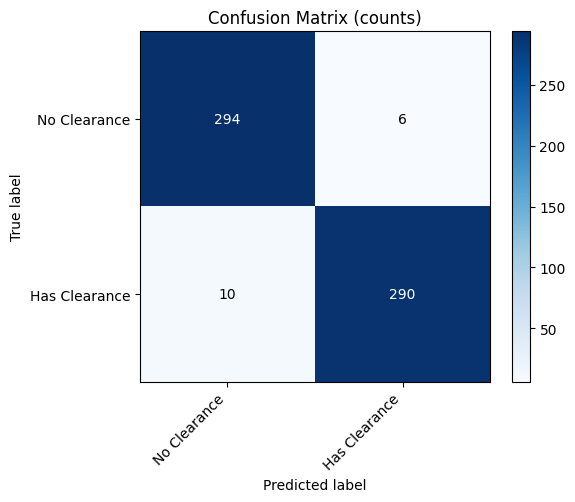

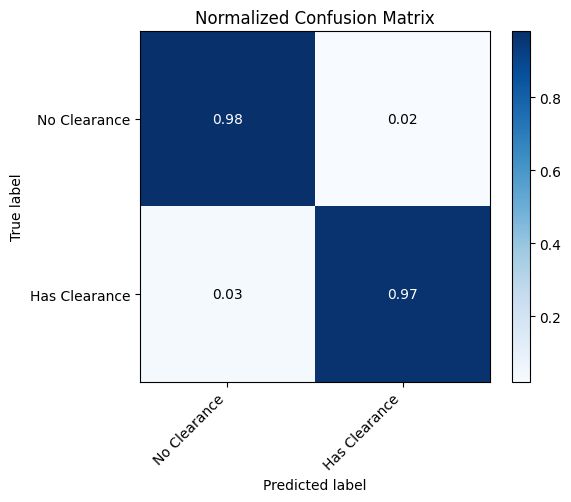

In [15]:
plot_confusion_matrix(cm, labels_cm, normalize=False); plt.show()
plot_confusion_matrix(cm, labels_cm, normalize=True);  plt.show()

## Metric Must Follow the Decision

Accuracy gives one number — but it can hide important imbalances.

**Example:** if 90% of samples are "no clearance", a model that always predicts "no clearance" gets 90% accuracy — and catches zero faults.

Better metrics for maintenance tasks:

| Metric | Formula | What it emphasizes |
|--------|---------|-------------------|
| **Precision** | TP / (TP + FP) | how many alarms are real |
| **Recall** | TP / (TP + FN) | how many faults are caught |
| **F1 score** | 2 · P · R / (P + R) | balance of precision and recall |
| **ROC-AUC** | area under ROC curve | overall discrimination ability |

**Choose your metric based on the cost asymmetry:**
- High cost of missed fault → maximize **Recall**
- High cost of false alarm → maximize **Precision**

## Discussion

Look at your confusion matrix results:

- Which error did the model make more often — false alarms or missed faults?
- For a **safety-critical** machine (e.g., aircraft landing gear), which threshold would you set?
- For a **cost-sensitive** application (e.g., scheduled maintenance), does your answer change?

> There is no universally correct answer — the right metric depends on *what failure costs in your domain*.

## Your Turn

### Try (5 min)

Increase **GRU hidden size** from 32 to 128 and retrain.

- Does accuracy change?
- Does the model train faster or slower?
- Look at the confusion matrix — *which* errors do change, not just the total?

### Extend (5–10 min)

Change the **window stride** from 50 to 100 (no overlap) in the data loading cell and regenerate.

- How many total sequences do you get now?
- Does the classification accuracy change?
- What does this tell you about the value of overlap?

> Re-run from the windowing cell through to evaluation.

### Explore (open-ended)

The current input uses only `acc1` and `acc2`.  
Change `used_vars` to `['vel', 'acc']` (generalized velocities and accelerations) and retrain.

- Does the model do better or worse with different sensor channels?
- What does this suggest about **feature selection** in real sensor deployments?

> Hint: `input_size` in `GRUClassifier` must match `X_train.shape[1]`.

## Session 2 Complete

You have now seen the full supervised learning pipeline applied to multibody dynamics:

| Notebook | Key idea |
|----------|---------|
| **2-1** | Learn ODE derivatives; local surrogate; rollout error |
| **2-2** | Trajectory-based surrogate; no equations needed |
| **2-3** | Grid search to find hyperparameters systematically |
| **2-4** | Classification; sequence models; maintenance context |

**Common thread:** define a mapping, generate data, train with backpropagation, evaluate on held-out data.

**Session 3** moves to a fundamentally different paradigm: the model learns *through interaction*, not from a fixed dataset.